<a href="https://colab.research.google.com/github/HoFangHuy/AI/blob/main/BTVN_BT_nh%C3%B3m_Bai3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from PIL import Image
import numpy as np

# Đường dẫn thư mục chứa dữ liệu đã chia
data_dir = r'/content/drive/MyDrive/Bài 3/dataset'
output_dir = r'/content/drive/MyDrive/Bài 3/dataset'  # Ghi đè lên thư mục gốc sau khi resize

# Kích thước mục tiêu
IMG_SIZE = (640, 640)

# Hàm resize và chuẩn hóa hình ảnh
def resize_and_normalize_image(image_path, output_path):
    # Đọc hình ảnh
    img = Image.open(image_path).convert('RGB')

    # Resize hình ảnh
    img = img.resize(IMG_SIZE, Image.Resampling.LANCZOS)

    # Chuyển thành numpy array và chuẩn hóa
    img_array = np.array(img) / 255.0

    # Chuyển lại thành hình ảnh và lưu
    img_normalized = Image.fromarray((img_array * 255).astype(np.uint8))
    img_normalized.save(output_path)

# Duyệt qua tất cả các thư mục (train, val) và các lớp (dat_yeu_cau, khong_dat_yeu_cau)
for split in ['train', 'val']:
    for category in ['dat_yeu_cau', 'khong_dat_yeu_cau']:
        input_path = os.path.join(data_dir, split, category)
        output_path = os.path.join(output_dir, split, category)

        # Đảm bảo thư mục đầu ra tồn tại
        os.makedirs(output_path, exist_ok=True)

        # Xử lý từng hình ảnh
        for img_name in os.listdir(input_path):
            img_path = os.path.join(input_path, img_name)
            out_path = os.path.join(output_path, img_name)

            if os.path.isfile(img_path):
                resize_and_normalize_image(img_path, out_path)

print("Resize và chuẩn hóa hình ảnh thành công!")

Resize và chuẩn hóa hình ảnh thành công!


In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Đường dẫn thư mục dữ liệu gốc và thư mục đích
dataset_dir = r"/content/drive/MyDrive/Bài 3/dataset_goc/cardboard_boxes"
output_dir = r'/content/drive/MyDrive/Bài 3/dataset'

# Tạo thư mục đầu ra nếu chưa tồn tại
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')

# Tạo các thư mục con
for category in ['dat_yeu_cau', 'khong_dat_yeu_cau']:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(val_dir, category), exist_ok=True)

# Chia dữ liệu cho từng lớp
for category in ['dat_yeu_cau', 'khong_dat_yeu_cau']:
    category_path = os.path.join(dataset_dir, category)
    images = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]

    # Chia tập train và val (70% train, 30% val)
    train_images, val_images = train_test_split(images, test_size=0.3, random_state=42)

    # Sao chép file vào thư mục train
    for img in train_images:
        src = os.path.join(category_path, img)
        dst = os.path.join(train_dir, category, img)
        shutil.copy(src, dst)

    # Sao chép file vào thư mục val
    for img in val_images:
        src = os.path.join(category_path, img)
        dst = os.path.join(val_dir, category, img)
        shutil.copy(src, dst)

print("Chia tập dữ liệu thành công!")

Chia tập dữ liệu thành công!


In [7]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

# Tắt oneDNN nếu không cần (tùy chọn)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Xây dựng mô hình
model = Sequential([
    Input(shape=(640, 640, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),  # Thay Flatten để giảm tham số
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Chuẩn bị dữ liệu
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Bài 3/dataset/train',
    target_size=(640, 640),
    batch_size=8,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/Bài 3/dataset/val',
    target_size=(640, 640),
    batch_size=8,
    class_mode='binary'
)

# Huấn luyện mô hình
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

# Đánh giá mô hình
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")

# Lưu mô hình
#model.save('cardboard_classifier.h5')

# (Tùy chọn) Dự đoán trên hình ảnh mới
# img = cv2.imread('test_image.jpg')
# img = cv2.resize(img, (640, 640))
# img = img / 255.0
# img = np.expand_dims(img, axis=0)
# prediction = model.predict(img)
# print("Đạt yêu cầu" if prediction[0] > 0.5 else "Không đạt yêu cầu")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 638, 638, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 638, 638, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 319, 319, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 317, 317, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 317, 317, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 158, 158, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 156, 156, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 156, 156, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 78, 78, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

Found 20 images belonging to 2 classes.
Found 13 images belonging to 2 classes.
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6313 - loss: 0.6328 - val_accuracy: 0.5385 - val_loss: 0.6909
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 856ms/step - accuracy: 0.9750 - loss: 0.2956 - val_accuracy: 0.5385 - val_loss: 0.6900
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 974ms/step - accuracy: 0.9750 - loss: 0.2557 - val_accuracy: 0.5385 - val_loss: 0.6886
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 0.1497 - val_accuracy: 0.5385 - val_loss: 0.6879
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 1.0000 - loss: 0.1450 - val_accuracy: 0.5385 - val_loss: 0.6900
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 866ms/step - accuracy: 1.0000 - loss: 0.1065 - val_accuracy: 0.5385 - val_loss: 0.6913
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 0.0440 - val_accuracy: 0.5385 - val_loss: 0.6914
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - 

In [8]:
model.save('bai3.h5')

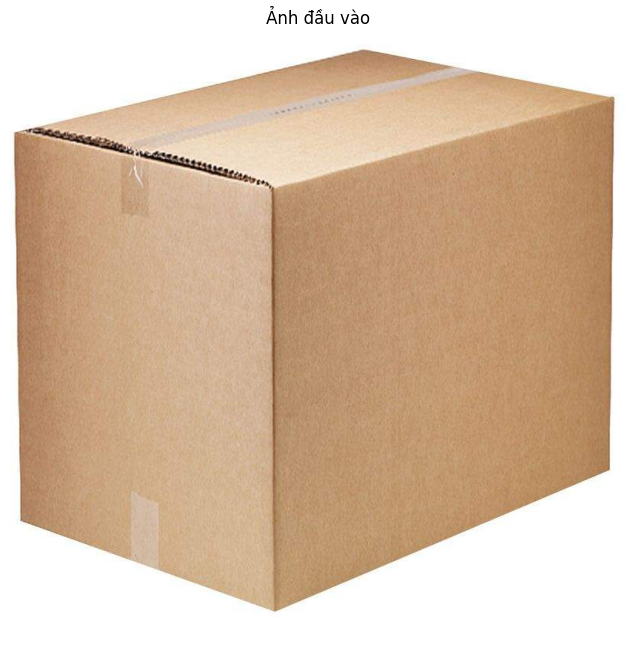

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Loại thùng giấy: Không đạt yêu cầu
Xác suất (đạt yêu cầu): 0.4376


In [20]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

image_path = r"/cho-ban-thung-carton-gia-re.jpg"
img = cv2.imread(image_path)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Ảnh đầu vào')
plt.show()

if img is None:
    print("Không thể đọc hình ảnh. Vui lòng kiểm tra đường dẫn:", image_path)
else:
    img = cv2.resize(img, (640, 640))

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    if prediction[0] > 0.5:
        print("Loại thùng giấy: Đạt yêu cầu")
    else:
        print("Loại thùng giấy: Không đạt yêu cầu")

    print(f"Xác suất (đạt yêu cầu): {prediction[0][0]:.4f}")